# 지도학습_분류분석_컬럼선택법_클래스불균형_모델성능향상시키기

# 중요 컬럼 선택하기
* 1) EDA를 통해서 종속변수(target)과 중요한 관계가 있는 변수들만 선택
* 2) 수치형 변수는 상관분석 결과를 통해, 범주형 변수는 카이제곱 통계량(통계학적 방법)
* 3) 머신러닝 알고리즘을 통한 1차 분석 후 중요하게 사용된 변수만 선택

# Tree 계열 모델의 Feature_Importance로 선택하기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [2]:
data = pd.read_csv("./data/salary2.csv")
data.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
data2 = data.copy()

In [4]:
data = data.drop_duplicates()

In [5]:
data = data.dropna()
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48835,53,Private,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
48836,22,Private,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [6]:
data = data.reset_index(drop=True)
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39235,53,Private,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
39236,22,Private,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
39237,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
39238,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [7]:
data['class'] = data['class'].apply(lambda x: 1 if x == ' >50K' else 0)

In [8]:
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39235,53,Private,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,1
39236,22,Private,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,0
39237,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
39238,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0


In [9]:
data = pd.get_dummies(data, drop_first=True)

In [10]:
X = data.drop('class', axis=1)

In [11]:
y = data['class']

In [12]:
X

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,25,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,9,0,0,50,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,12,0,0,40,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,10,7688,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,34,6,0,0,30,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39235,53,14,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
39236,22,10,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
39237,27,12,0,0,38,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
39238,58,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [13]:
y

0        0
1        0
2        1
3        1
4        0
        ..
39235    1
39236    0
39237    0
39238    0
39239    1
Name: class, Length: 39240, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=10)

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [17]:
dtc = DecisionTreeClassifier(max_depth=9, random_state=10)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90     11706
           1       0.77      0.58      0.66      3990

    accuracy                           0.85     15696
   macro avg       0.82      0.76      0.78     15696
weighted avg       0.84      0.85      0.84     15696



# feature_importance 출력하기

In [18]:
importance = pd.DataFrame(dtc.feature_importances_)

In [19]:
cols = pd.DataFrame(dtc.feature_names_in_)

In [20]:
important_cols = pd.concat([cols, importance], axis=1)

In [21]:
important_cols.columns = ['column', 'importance']
important_cols

,column,importance
0,age,0.038730
1,education-num,0.194695
2,capital-gain,0.216183
3,capital-loss,0.078845
4,hours-per-week,0.031110
...,...,...
90,native-country_ Thailand,0.000000
91,native-country_ Trinadad&Tobago,0.000000
92,native-country_ United-States,0.000000
93,native-country_ Vietnam,0.000000


In [22]:
important_cols = important_cols.sort_values(by='importance', ascending=False)

In [23]:
important_cols[important_cols['importance'] > 0]

,column,importance
27,marital-status_ Married-civ-spouse,0.400573
2,capital-gain,0.216183
1,education-num,0.194695
3,capital-loss,0.078845
0,age,0.038730
4,hours-per-week,0.031110
34,occupation_ Exec-managerial,0.011520
8,workclass_ Self-emp-not-inc,0.006948
35,occupation_ Farming-fishing,0.004866
54,sex_ Male,0.003542


# random_forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
rfc = RandomForestClassifier(random_state=10)
rfc.fit(X_train, y_train)
pred = rfc.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.87      0.90      0.89     11706
           1       0.68      0.60      0.64      3990

    accuracy                           0.83     15696
   macro avg       0.77      0.75      0.76     15696
weighted avg       0.82      0.83      0.82     15696



In [26]:
importance2 = pd.DataFrame(rfc.feature_importances_, columns=['importance'])
column2 = pd.DataFrame(rfc.feature_names_in_, columns=['column'])
rfc_importance = pd.concat([column2, importance2], axis=1)
rfc_importance

,column,importance
0,age,0.229726
1,education-num,0.060181
2,capital-gain,0.122142
3,capital-loss,0.041190
4,hours-per-week,0.117826
...,...,...
90,native-country_ Thailand,0.000140
91,native-country_ Trinadad&Tobago,0.000107
92,native-country_ United-States,0.006653
93,native-country_ Vietnam,0.000283


In [27]:
rfc_importance[rfc_importance['importance'] > 0]

,column,importance
0,age,0.229726
1,education-num,0.060181
2,capital-gain,0.122142
3,capital-loss,0.041190
4,hours-per-week,0.117826
...,...,...
90,native-country_ Thailand,0.000140
91,native-country_ Trinadad&Tobago,0.000107
92,native-country_ United-States,0.006653
93,native-country_ Vietnam,0.000283


In [28]:
rfc_importance = rfc_importance[rfc_importance['importance'] > 0.01].sort_values(by="importance", ascending=False)
rfc_importance

,column,importance
0,age,0.229726
2,capital-gain,0.122142
4,hours-per-week,0.117826
27,marital-status_ Married-civ-spouse,0.083482
1,education-num,0.060181
3,capital-loss,0.041190
29,marital-status_ Never-married,0.034063
34,occupation_ Exec-managerial,0.019778
54,sex_ Male,0.019321
45,relationship_ Not-in-family,0.017576


# xgboost

In [29]:
from xgboost import XGBClassifier

In [30]:
xgb = XGBClassifier(random_state=10)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91     11706
           1       0.77      0.67      0.71      3990

    accuracy                           0.86     15696
   macro avg       0.83      0.80      0.81     15696
weighted avg       0.86      0.86      0.86     15696



In [31]:
importance3 = pd.DataFrame(xgb.feature_importances_, columns=['importance'])
column3 = pd.DataFrame(xgb.feature_names_in_, columns=['column'])
importance3 = pd.concat([column3, importance3], axis=1)
importance3 = importance3[importance3['importance'] > 0.01].sort_values(by='importance', ascending=False)
importance3

,column,importance
27,marital-status_ Married-civ-spouse,0.413689
2,capital-gain,0.058502
1,education-num,0.046971
38,occupation_ Other-service,0.033853
3,capital-loss,0.024621
35,occupation_ Farming-fishing,0.023159
34,occupation_ Exec-managerial,0.021343
47,relationship_ Own-child,0.015753
40,occupation_ Prof-specialty,0.013670
79,native-country_ Mexico,0.013073


In [61]:
data2.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'class'],
      dtype='object')

In [32]:
data2 = data2.drop_duplicates()
data2 = data2.dropna()
data3 = data2[['age', 'marital-status', 'capital-gain', 'capital-loss', 'sex', 'education-num', 'occupation', 'class']]

In [33]:
data3 = data3.reset_index(drop=True)
print(data3.columns)
data3

Index(['age', 'marital-status', 'capital-gain', 'capital-loss', 'sex',
       'education-num', 'occupation', 'class'],
      dtype='object')


,age,marital-status,capital-gain,capital-loss,sex,education-num,occupation,class
0,25,Never-married,0,0,Male,7,Machine-op-inspct,<=50K
1,38,Married-civ-spouse,0,0,Male,9,Farming-fishing,<=50K
2,28,Married-civ-spouse,0,0,Male,12,Protective-serv,>50K
3,44,Married-civ-spouse,7688,0,Male,10,Machine-op-inspct,>50K
4,34,Never-married,0,0,Male,6,Other-service,<=50K
...,...,...,...,...,...,...,...,...
39235,53,Married-civ-spouse,0,0,Male,14,Exec-managerial,>50K
39236,22,Never-married,0,0,Male,10,Protective-serv,<=50K
39237,27,Married-civ-spouse,0,0,Female,12,Tech-support,<=50K
39238,58,Widowed,0,0,Female,9,Adm-clerical,<=50K


In [34]:
data3 = pd.get_dummies(data3, drop_first=True)

In [35]:
data3

,age,capital-gain,capital-loss,education-num,marital-status_ Married-AF-spouse,marital-status_ Married-civ-spouse,marital-status_ Married-spouse-absent,marital-status_ Never-married,marital-status_ Separated,marital-status_ Widowed,...,occupation_ Handlers-cleaners,occupation_ Machine-op-inspct,occupation_ Other-service,occupation_ Priv-house-serv,occupation_ Prof-specialty,occupation_ Protective-serv,occupation_ Sales,occupation_ Tech-support,occupation_ Transport-moving,class_ >50K
0,25,0,0,7,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
1,38,0,0,9,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,28,0,0,12,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
3,44,7688,0,10,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,34,0,0,6,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39235,53,0,0,14,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
39236,22,0,0,10,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
39237,27,0,0,12,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
39238,58,0,0,9,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [36]:
X = data3.drop('class_ >50K', axis=1)
y = data3['class_ >50K']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=10)

In [38]:
xgb = XGBClassifier(random_state=10)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

       False       0.89      0.93      0.91     11706
        True       0.77      0.65      0.70      3990

    accuracy                           0.86     15696
   macro avg       0.83      0.79      0.81     15696
weighted avg       0.86      0.86      0.86     15696



In [39]:
importance3 = pd.DataFrame(xgb.feature_importances_, columns=['importance'])
column3 = pd.DataFrame(xgb.feature_names_in_, columns=['column'])
importance3 = pd.concat([column3, importance3], axis=1)
importance3 = importance3[importance3['importance'] > 0.01].sort_values(by='importance', ascending=False)
importance3

,column,importance
5,marital-status_ Married-civ-spouse,0.473459
1,capital-gain,0.090947
3,education-num,0.057546
17,occupation_ Other-service,0.056346
14,occupation_ Farming-fishing,0.047047
13,occupation_ Exec-managerial,0.039511
2,capital-loss,0.035579
19,occupation_ Prof-specialty,0.028145
22,occupation_ Tech-support,0.021765
15,occupation_ Handlers-cleaners,0.017977


In [92]:
y.value_counts()

class_ >50K
False    29265
True      9975
Name: count, dtype: int64

# 클래스 불균형을 처리하는 방법
* 클래스 불균형: 종속변수(target)의 클래스(값, 요소)의 비율이 일치하지 않는 경우
* 연봉 데이터의 경우 >50k 가 1, <= 50k 가 3의 비율을 가지고 있음.
* train_test_split시 stratify= 옵션을 반드시 포함
* 머신러닝 알고리즘에 있는 소수 클래스에 가중치를 주는 옵션 on

decisionTree 모델의 경우 class_weight="balanced"

In [40]:
dtc = DecisionTreeClassifier(class_weight="balanced", random_state=10)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

       False       0.90      0.81      0.85     11706
        True       0.57      0.75      0.65      3990

    accuracy                           0.79     15696
   macro avg       0.74      0.78      0.75     15696
weighted avg       0.82      0.79      0.80     15696



In [41]:
# for i in range(1, 20):
#     dtc = DecisionTreeClassifier(max_depth=i, class_weight="balanced", random_state=10)
#     dtc.fit(X_train, y_train)
#     pred = dtc.predict(X_test)
#     print(i)
#     print(classification_report(y_test, pred))
#     print()

random_forest의 경우 class_weight="balanced"

In [42]:
# for i in range(1, 20):
#     rfc = RandomForestClassifier(max_depth=i, n_estimators=100, n_jobs=-1, random_state=10)
#     rfc.fit(X_train, y_train)
#     pred = rfc.predict(X_test)
#     print(i)
#     print(classification_report(y_test, pred))
#     print()

In [43]:
# for i in range(1, 20):
#     rfc = RandomForestClassifier(max_depth=i, n_estimators=100, n_jobs=-1, class_weight="balanced", random_state=10)
#     rfc.fit(X_train, y_train)
#     pred = rfc.predict(X_test)
#     print(i)
#     print(classification_report(y_test, pred))
#     print()

In [98]:
for i in range(1, 20):
    rfc = RandomForestClassifier(max_depth=i, n_estimators=100, n_jobs=-1, class_weight="balanced", random_state=10)
    rfc.fit(X_train, y_train)
    pred = rfc.predict(X_test)
    print(i)
    print(classification_report(y_test, pred))
    print()

1
              precision    recall  f1-score   support

       False       0.93      0.72      0.81     11706
        True       0.51      0.84      0.63      3990

    accuracy                           0.75     15696
   macro avg       0.72      0.78      0.72     15696
weighted avg       0.82      0.75      0.77     15696


2
              precision    recall  f1-score   support

       False       0.93      0.71      0.81     11706
        True       0.50      0.85      0.63      3990

    accuracy                           0.75     15696
   macro avg       0.72      0.78      0.72     15696
weighted avg       0.82      0.75      0.76     15696


3
              precision    recall  f1-score   support

       False       0.94      0.73      0.82     11706
        True       0.52      0.86      0.65      3990

    accuracy                           0.76     15696
   macro avg       0.73      0.79      0.73     15696
weighted avg       0.83      0.76      0.78     15696


4
        

xgboost scale_pos_weight=3

In [136]:
# for i in range(1, 21):
#     xgb = XGBClassifier(max_depth=i, n_estimators=500, scale_pos_weight=3, n_jobs=-1, random_state=10)
#     xgb.fit(X_train, y_train)
#     pred = xgb.predict(X_test)
#     print(i)
#     print(classification_report(y_test, pred))
#     print()

lightgbm is_unbalace=True

In [44]:
from lightgbm import LGBMClassifier

In [45]:
# for i in range(1, 21):
#     lgbm = LGBMClassifier(max_depth=i, n_estimators=500, is_unbalance=True, n_jobs=-1, random_state=10, verbose=-1)
#     lgbm.fit(X_train, y_train)
#     pred = lgbm.predict(X_test)
#     print(i)
#     print(classification_report(y_test, pred))
#     print()

# 데이터를 증폭 / 축소해서 class 불균형 해소
* imbalanced-learn, smote/cluster-centroids
* 머신러닝 알고리즘을 통해 비슷한 데이터를 생성/축소
* **반드시 train 데이터에만 적용**

In [46]:
X_train

,age,capital-gain,capital-loss,education-num,marital-status_ Married-AF-spouse,marital-status_ Married-civ-spouse,marital-status_ Married-spouse-absent,marital-status_ Never-married,marital-status_ Separated,marital-status_ Widowed,...,occupation_ Farming-fishing,occupation_ Handlers-cleaners,occupation_ Machine-op-inspct,occupation_ Other-service,occupation_ Priv-house-serv,occupation_ Prof-specialty,occupation_ Protective-serv,occupation_ Sales,occupation_ Tech-support,occupation_ Transport-moving
21251,32,0,0,4,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3994,38,0,0,10,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1871,58,0,0,13,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
16563,27,0,0,9,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
16892,46,0,0,13,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15385,25,0,1340,13,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
37453,34,0,0,5,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
14106,25,0,0,9,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
20368,70,0,0,9,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [47]:
y_train

21251    False
3994     False
1871      True
16563    False
16892     True
         ...  
15385    False
37453    False
14106    False
20368    False
36269    False
Name: class_ >50K, Length: 23544, dtype: bool

In [48]:
len(y_train)

23544

In [49]:
y_train.value_counts()

class_ >50K
False    17559
True      5985
Name: count, dtype: int64

In [50]:
X_train.shape[1]

24

In [51]:
list(range(4, X_train.shape[1]))

[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

In [52]:
from imblearn.over_sampling import SMOTENC

In [53]:
smt = SMOTENC(categorical_features=list(range(4, X_train.shape[1])) ,k_neighbors=5, n_jobs=-1, random_state=10)
smt_X, smt_y = smt.fit_resample(X_train, y_train)

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\imblearn\over_sampling\_smote\base.py:645: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


In [54]:
len(smt_y)

35118

In [55]:
smt_y.value_counts()

class_ >50K
False    17559
True     17559
Name: count, dtype: int64

In [56]:
len(smt_X)

35118

In [58]:
# 원래 데이터
dtc = DecisionTreeClassifier(max_depth=9, random_state=10)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

       False       0.87      0.94      0.90     11706
        True       0.76      0.58      0.66      3990

    accuracy                           0.85     15696
   macro avg       0.81      0.76      0.78     15696
weighted avg       0.84      0.85      0.84     15696



smotenc로 증폭한 데이터로 분석

In [59]:
dtc2 = DecisionTreeClassifier(max_depth=9, random_state=10)
dtc2.fit(smt_X, smt_y)
pred2 = dtc2.predict(X_test)
print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

       False       0.94      0.78      0.85     11706
        True       0.57      0.85      0.68      3990

    accuracy                           0.80     15696
   macro avg       0.76      0.82      0.77     15696
weighted avg       0.85      0.80      0.81     15696



#### 정확도가 5나 떨어졌는데 성능이 더 안 좋은 것 아닌가?
* 정확도가 높다고 해서 좋은 모델이 아니다
* **원래 데이터 모델**
  * 전체 정확도는 높음 (0.85)
  * 하지만 True(1) 클래스 재현율(recall)이 낮음 (0.58) <br> → 소수 클래스(사기거래 등)를 많이 놓침

* **SMOTENC 데이터 모델**

  * 전체 정확도는 낮아졌지만 (0.80)
  * True(1) 클래스 재현율이 확 올라감 (0.85) <br> → 소수 클래스를 훨씬 더 잘 잡음
  * Precision(정밀도)은 좀 낮아짐 (0.57) <br> → 잡았지만 틀린 것도 꽤 있음

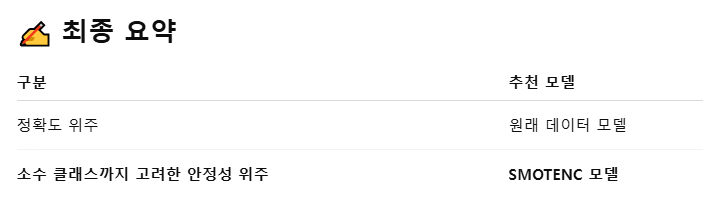

In [60]:
for i in range(1, 21):
    rfc2 = RandomForestClassifier(max_depth=i, n_estimators=100, n_jobs=-1,random_state=10)
    rfc2.fit(smt_X, smt_y)
    rfc2_pred = rfc2.predict(X_test)
    print(i)
    print(classification_report(y_test, rfc2_pred))
    print()

1
              precision    recall  f1-score   support

       False       0.94      0.68      0.79     11706
        True       0.48      0.86      0.62      3990

    accuracy                           0.73     15696
   macro avg       0.71      0.77      0.70     15696
weighted avg       0.82      0.73      0.75     15696


2
              precision    recall  f1-score   support

       False       0.94      0.70      0.80     11706
        True       0.50      0.87      0.64      3990

    accuracy                           0.75     15696
   macro avg       0.72      0.79      0.72     15696
weighted avg       0.83      0.75      0.76     15696


3
              precision    recall  f1-score   support

       False       0.94      0.71      0.81     11706
        True       0.51      0.87      0.64      3990

    accuracy                           0.75     15696
   macro avg       0.72      0.79      0.72     15696
weighted avg       0.83      0.75      0.77     15696


4
        

In [61]:
for i in range(1, 21):
    lgbm = LGBMClassifier(max_depth=i, n_estimators=500, n_jobs=-1, random_state=10, verbose=-1)
    lgbm.fit(smt_X, smt_y)
    pred = lgbm.predict(X_test)
    print(i)
    print(classification_report(y_test, pred))
    print()

1
              precision    recall  f1-score   support

       False       0.93      0.80      0.86     11706
        True       0.59      0.83      0.69      3990

    accuracy                           0.81     15696
   macro avg       0.76      0.82      0.78     15696
weighted avg       0.85      0.81      0.82     15696


2
              precision    recall  f1-score   support

       False       0.94      0.81      0.87     11706
        True       0.61      0.85      0.71      3990

    accuracy                           0.82     15696
   macro avg       0.78      0.83      0.79     15696
weighted avg       0.86      0.82      0.83     15696


3
              precision    recall  f1-score   support

       False       0.94      0.81      0.87     11706
        True       0.61      0.86      0.71      3990

    accuracy                           0.82     15696
   macro avg       0.77      0.83      0.79     15696
weighted avg       0.86      0.82      0.83     15696


4
        

# k-fold, 하이퍼파라미터 튜닝
* k-fold 교차검증: 훈련에 사용할 데이터를 여러 번 나누어서 편향을 줄이고 모델을 균형 잡히게 하는 방법
* 하이퍼파라미터 튜닝: 머신러닝 알고리즘에 있는 여러 파라미터를 조정해서 최고의 성능을 내는 모델을 만드는 것. <br>max_depth, n_estimators, learning_rate
* gridsearch, randomsearch
* gridsearch: 지정해 놓은 모든 경우의 수의 하이퍼파라미터를 탐색
* randomsearch: 지정해 놓은 범위 내에서 랜덤하게 탐색

In [62]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [63]:
model = DecisionTreeClassifier(random_state=10)

In [64]:
params = dict(criterion=["gini", "entropy", "log_loss"],
              max_depth=[1, 5, 10, 15],
              random_state=[7, 10, 777],
              class_weight=[None, "balanced"])

In [65]:
grid_cv = GridSearchCV(model, param_grid=params, cv=3 ,n_jobs=-1)
grid_cv.fit(X_train, y_train)
pred = grid_cv.predict(X_test)
print("best_params: ", grid_cv.best_params_)
print("best_score_: ", grid_cv.best_score_)

best_params:  {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'random_state': 777}
best_score_:  0.8497706422018348


In [ ]:
grid_cv = GridSearchCV(model, param_grid=params, cv=3 ,n_jobs=-1)
grid_cv.fit(X_train, y_train)
pred = grid_cv.predict(X_test)
print("best_params: ", grid_cv.best_params_)
print("best_score_: ", grid_cv.best_score_)

In [67]:
model2 = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=777)
model2.fit(X_train, y_train)
pred = model2.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

       False       0.87      0.94      0.90     11706
        True       0.76      0.57      0.66      3990

    accuracy                           0.85     15696
   macro avg       0.81      0.76      0.78     15696
weighted avg       0.84      0.85      0.84     15696



In [68]:
params = dict(criterion=["gini", "entropy", "log_loss"],
              max_depth=[8, 9, 10, 11, 12],
              random_state=[777],
              class_weight=[None, "balanced"])

gridSearch에서 score기준 변경하기
* scoring=[accuracy, precision, recall, f1, roc_auc]

In [171]:
model3 = DecisionTreeClassifier(random_state=10)

In [69]:
grid_cv = GridSearchCV(model, param_grid=params, scoring='recall',  cv=3 ,n_jobs=-1)
grid_cv.fit(X_train, y_train)
pred = grid_cv.predict(X_test)
print("best_params: ", grid_cv.best_params_)
print("best_score_: ", grid_cv.best_score_)

best_params:  {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'random_state': 777}
best_score_:  0.8619883040935673


In [70]:
model3 = DecisionTreeClassifier(criterion='gini', class_weight='balanced', max_depth=10, random_state=777)
model3.fit(X_train, y_train)
pred = model3.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

       False       0.95      0.76      0.84     11706
        True       0.55      0.87      0.68      3990

    accuracy                           0.79     15696
   macro avg       0.75      0.82      0.76     15696
weighted avg       0.85      0.79      0.80     15696



클래스 0에 대한 score를 계산하고 싶을 때

In [71]:
from sklearn.metrics import make_scorer, recall_score, precision_score, accuracy_score

In [72]:
recall_0_scorer = make_scorer(recall_score, pos_label=0)

In [73]:
grid_cv = GridSearchCV(model, param_grid=params, scoring=recall_0_scorer,  cv=3 ,n_jobs=-1)
grid_cv.fit(X_train, y_train)
pred = grid_cv.predict(X_test)
print("best_params: ", grid_cv.best_params_)
print("best_score_: ", grid_cv.best_score_)

best_params:  {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'random_state': 777}
best_score_:  0.9423657383677887


In [74]:
model3 = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=777)
model3.fit(X_train, y_train)
pred = model3.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

       False       0.87      0.94      0.90     11706
        True       0.76      0.57      0.66      3990

    accuracy                           0.85     15696
   macro avg       0.81      0.76      0.78     15696
weighted avg       0.84      0.85      0.84     15696



# randomSearch
* 지정한 파라미터 값에서 랜덤성을 더해서 최적값을 찾아냄

In [75]:
from sklearn.model_selection import RandomizedSearchCV

In [76]:
dtc = DecisionTreeClassifier(random_state=10)

In [77]:
params = dict(criterion=["gini", "entropy", "log_loss"],
              max_depth=[1, 5, 10, 15],
              random_state=[7, 10, 777],
              class_weight=[None, "balanced"])

In [78]:
rand_cv = RandomizedSearchCV(model, param_distributions=params, scoring='f1',
                            cv=3 ,n_jobs=-1, random_state=10)
rand_cv.fit(X_train, y_train)
pred = rand_cv.predict(X_test)
print("best_params: ", rand_cv.best_params_)
print("best_score_: ", rand_cv.best_score_)

best_params:  {'random_state': 10, 'max_depth': 15, 'criterion': 'entropy', 'class_weight': 'balanced'}
best_score_:  0.6847937213314063


In [83]:
rand_cv = GridSearchCV(model, param_grid=params, scoring=recall_0_scorer, cv=3, n_jobs=-1)
rand_cv.fit(X_train, y_train)
pred = rand_cv.predict(X_test)
print("best_params: ", rand_cv.best_params_)
print("best_score: ", rand_cv.best_score_)

best_params:  {'class_weight': None, 'criterion': 'gini', 'max_depth': 1, 'random_state': 7}
best_score:  1.0


In [84]:
model4 = DecisionTreeClassifier(random_state=10, max_depth=15, criterion='entropy', class_weight='balanced')
model4.fit(X_train, y_train)
pred = model4.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

       False       0.94      0.78      0.85     11706
        True       0.56      0.85      0.68      3990

    accuracy                           0.79     15696
   macro avg       0.75      0.81      0.76     15696
weighted avg       0.84      0.79      0.80     15696



XGBoost를 랜덤서치로 하이퍼파라미터 튜닝하기

In [80]:
xgb = XGBClassifier(n_jobs=-1, random_state=10)

In [81]:
xgb_params = dict(n_estimators=[100, 500, 1000],
                 max_depth=[1, 5, 10, 15, 20],
                 learning_rate=[0.1, 0.5, 1],
                 booster=['gbtree', 'gblinear',  'dart'],
                 scale_pos_weight=[0, 3],
                 )

In [82]:
rand_cv = RandomizedSearchCV(xgb, param_distributions=xgb_params,
                            cv=3, scoring='roc_auc', random_state=10)
rand_cv.fit(X_train, y_train)
pred = rand_cv.predict(X_test)
print("best_params: ", rand_cv.best_params_)
print("best_score_: ", rand_cv.best_score_)

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\xgboost\core.py:158: UserWarning: [10:21:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "max_depth" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\xgboost\core.py:158: UserWarning: [10:21:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "max_depth" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\xgboost\core.py:158: UserWarning: [10:21:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "max_depth" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\Admin\miniforge3

best_params:  {'scale_pos_weight': 3, 'n_estimators': 1000, 'max_depth': 1, 'learning_rate': 0.5, 'booster': 'gbtree'}
best_score_:  0.9191755229522637


In [85]:
from sklearn.metrics import roc_auc_score

In [86]:
xgb2 = XGBClassifier(n_jobs=-1, random_state=10,
                    scale_pos_weight=3, n_estimators=1000,
                    max_depth=1, learning_rate=0.5, booster='gbtree')
xgb2.fit(X_train, y_train)
pred = xgb2.predict(X_test)
print(classification_report(y_test, pred))
print(roc_auc_score(y_test, pred))

              precision    recall  f1-score   support

       False       0.94      0.82      0.87     11706
        True       0.61      0.85      0.71      3990

    accuracy                           0.82     15696
   macro avg       0.78      0.83      0.79     15696
weighted avg       0.86      0.82      0.83     15696

0.8331782171985577


# 데이터 분석 과정 재정리
* 1) 데이터 선택 및 로딩
* 2) 결측값, 이상값 탐지
* 3) EDA(탐색적 데이터 분석)
* 4) 변수 데이터타입, 서열변수, 카테고리변수 처리
* 5) 변수 선택, 파생변수 생성
* 6) 홀드아웃(훈련 데이터, 테스트 데이터로 분리)
* 7) 분석에 맞는 알고리즘 불러와서 모델 생성
* 8) 분석 목적에 맞는 지표를 이용해서 모델 성능 검증
* 9) 하이퍼파라미터 튜닝(클래스 불균형 해소 - 모델에서 소수 클래스 가중치 조절, 데이터 증폭, 축소)
* 10) 최종 모델 선택
#### 데이터전처리(1~5번)과정이 데이터 분석 대부분의 시간을 잡아먹는다